# I. Wilcoxon sum ranked test
To test if mutation rate of one locus is significantly different from another locus of the same gene.

## a. First need to add arbitrary gene code to the mapped files so the mapped mutations can be grouped per gene

### For mapped files that have strand info in the last column

In [4]:
def process_files_efficient(input_file1, input_file2, output_file):
    # Step 1: Process input file 1 and store ranges in a dictionary by chromosome
    ranges_by_chrom = {}
    gene_code = 1
    
    with open(input_file1, 'r') as f1:
        for line in f1:
            if line.strip():
                parts = line.strip().split()
                chrom = parts[0]
                start = int(parts[1])
                end = int(parts[2])
                strand = parts[3]
                
                if chrom not in ranges_by_chrom:
                    ranges_by_chrom[chrom] = []
                
                # For negative strand, start > end, so we need to handle this
                if strand == '-':
                    ranges_by_chrom[chrom].append({
                        'start': end,
                        'end': start,
                        'strand': strand,
                        'gene_code': gene_code
                    })
                else:
                    ranges_by_chrom[chrom].append({
                        'start': start,
                        'end': end,
                        'strand': strand,
                        'gene_code': gene_code
                    })
                gene_code += 1

    # Step 2: Process input file 2 and write directly to output
    with open(input_file2, 'r') as f2, open(output_file, 'w') as out_f:
        for line in f2:
            if line.strip():
                parts = line.strip().split()
                chrom_str = parts[-3]  # Second last column is chromosome (could be number or 'X')
                position_str = parts[-2]  # Third last column is position
                strand = parts[-1]  # Last column is strand
                
                # Convert chromosome to match file1 format
                if chrom_str.isdigit():
                    chrom = f"chr{chrom_str}"
                else:
                    chrom = f"chr{chrom_str}"  # This handles 'X', 'Y', etc.
                
                # Convert position to integer
                try:
                    position = int(position_str)
                except ValueError:
                    # If position can't be converted, skip this line or handle appropriately
                    out_f.write(f"{' '.join(parts)} NA\n")
                    continue
                
                # Find matching range
                found_gene_code = None
                if chrom in ranges_by_chrom:
                    for range_info in ranges_by_chrom[chrom]:
                        if (range_info['start'] <= position <= range_info['end'] and
                            range_info['strand'] == strand):
                            found_gene_code = range_info['gene_code']
                            break
                
                # Write the result
                if found_gene_code is not None:
                    out_f.write(f"{' '.join(parts)} {found_gene_code}\n")
                else:
                    out_f.write(f"{' '.join(parts)} NA\n")
        # Step 2: Process input file 2 and write directly to output
    processed_count = 0
    matched_count = 0


# Usage
process_files_efficient('lncRNA/results/lncrna_non_testis_tss_hg38_final.txt', 'lncRNA/results/rareSNP_mapped_lncrna_non_testis_strand_complement.txt', 'lncRNA/results/rareSNP_mapped_lncrna_non_testis_strand_complement_coded.txt')

### For mapped files that don't have strand info in the last column

In [1]:

#########################
def process_files_efficient(input_file1, input_file2, output_file):
    # Step 1: Process input file 1 and store ranges in a dictionary by chromosome
    ranges_by_chrom = {}
    gene_code = 1
    
    print("Processing input file 1...")
    with open(input_file1, 'r') as f1:
        for line in f1:
            if line.strip():
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                    
                chrom = parts[0]
                try:
                    start = int(parts[1])
                    end = int(parts[2])
                except ValueError:
                    continue
                    
                strand = parts[3]
                
                if chrom not in ranges_by_chrom:
                    ranges_by_chrom[chrom] = []
                
                # For negative strand, start > end, so we need to handle this
                if strand == '-':
                    ranges_by_chrom[chrom].append({
                        'start': end,
                        'end': start,
                        'gene_code': gene_code
                    })
                else:
                    ranges_by_chrom[chrom].append({
                        'start': start,
                        'end': end,
                        'gene_code': gene_code
                    })
                gene_code += 1
    
    print(f"Found {gene_code-1} ranges across {len(ranges_by_chrom)} chromosomes")
    
    # Step 2: Process input file 2 and write directly to output
    processed_count = 0
    matched_count = 0
    
    with open(input_file2, 'r') as f2, open(output_file, 'w') as out_f:
        for line in f2:
            if line.strip():
                parts = line.strip().split()
                # For the new format: second last column is chromosome, last column is position
                #if len(parts) < 12:  # For RareSNP
                #if len(parts) < 8:   # For DNM Roulette
                if len(parts) < 7:   # For DNM Decode
                    out_f.write(f"{' '.join(parts)} NA\n")
                    continue
                    
                chrom_str = parts[-2]  # Second last column is chromosome
                position_str = parts[-1]  # Last column is position
                
                # Convert chromosome to match file1 format
                if chrom_str.isdigit():
                    chrom = f"chr{chrom_str}"
                else:
                    chrom = f"chr{chrom_str}"  # This handles 'X', 'Y', etc.
                
                # Convert position to integer
                try:
                    position = int(position_str)
                except ValueError:
                    out_f.write(f"{' '.join(parts)} NA\n")
                    processed_count += 1
                    continue
                
                # Find matching range (no strand check needed)
                found_gene_code = None
                if chrom in ranges_by_chrom:
                    for range_info in ranges_by_chrom[chrom]:
                        if range_info['start'] <= position <= range_info['end']:
                            found_gene_code = range_info['gene_code']
                            matched_count += 1
                            break
                
                # Write the result
                if found_gene_code is not None:
                    out_f.write(f"{' '.join(parts)} {found_gene_code}\n")
                else:
                    out_f.write(f"{' '.join(parts)} NA\n")
                
                processed_count += 1

#process_files_efficient('Fantom5_CAGE_hg38_gencode.v40_TSS_1kb.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_TSS_mapped_noindel.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_TSS_mapped_noindel_coded.txt')
#process_files_efficient('FANTOM_CAT_Testis_lncRNA_coordinates_bestTSS_1kb_around_hg38.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_testis_lncRNA_mapped_noindel.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_testis_lncRNA_mapped_noindel_coded.txt')
#process_files_efficient('Human_Protein_Coding_Genes_GTF_Best_TSS_1kb_noexpress.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_noexpress_mapped_noindel.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_noexpress_mapped_noindel_coded.txt')
#process_files_efficient('human_intergenic_random_1kb.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_random_intergenic_mapped_noindel.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_random_intergenic_mapped_noindel_coded.txt')
process_files_efficient('/home/alexpalazzo1/Documents/Tina/Rare_SNP/lncRNA/results/lncrna_non_testis_tss_hg38_final.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_lncRNA_noexpress_mapped_noindel.txt', '/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_lncRNA_noexpress_mapped_noindel_coded.txt')

Processing input file 1...
Found 12577 ranges across 26 chromosomes


## b. Count the sum of all mutations per region, per gene

### Overall

In [21]:
def process_gene_data(input_file, output_file):
    # Initialize dictionary to store counts for each gene code
    gene_counts = {}
    all_gene_codes = set()
    
    # Define the ranges
    ranges = {
        'Upstream': (200, 300),
        'Middle': (450, 550),
        'Downstream': (700, 800)
    }
    
    # Read and process the input file
    with open(input_file, 'r') as f:
        for line in f:
            # Skip empty lines
            if not line.strip():
                continue
                
            # Split the line into columns
            columns = line.split()
            
            # Extract relevant information
            try:
                position = int(columns[0])
                gene_code = int(columns[-1])  # Last column is gene code
            except (ValueError, IndexError):
                continue  # Skip lines with invalid data
            
            # Add gene code to our set
            all_gene_codes.add(gene_code)
                
            # Initialize gene entry if it doesn't exist
            if gene_code not in gene_counts:
                gene_counts[gene_code] = {
                    'Upstream': 0,
                    'Middle': 0,
                    'Downstream': 0
                }
            
            # Check which range the position falls into and count it
            for range_name, (start, end) in ranges.items():
                if start <= position <= end:
                    gene_counts[gene_code][range_name] += 1
                    break
    
    # Convert to sorted list
    sorted_gene_codes = sorted(all_gene_codes)
    
    # Write output file
    with open(output_file, 'w') as f:
        # Write header
        f.write("Gene_code\tUpstream_count (200-300)\tMiddle_count (450-550)\tDownstream_count (700-800)\n")
        
        # Write data for all gene codes found in the input
        for gene_code in sorted_gene_codes:
            counts = gene_counts[gene_code]
            
            # Helper function to calculate value safely
            def calculate_value(count):
                if count == 0:
                    return 0  # Or some other default value you prefer
                ratio = count / 100
                if ratio == 1:
                    # Handle the case where ratio = 1 (division by zero)
                    # You might want to use a large number or skip
                    return float('inf')  # Or some large number, or skip this gene
                else:
                    return (ratio / (1 - ratio)) / 71702 / 119.39443
            
            upstream_count = calculate_value(counts['Upstream'])
            middle_count = calculate_value(counts['Middle'])
            downstream_count = calculate_value(counts['Downstream'])
            
            f.write(f"{gene_code}\t{upstream_count}\t{middle_count}\t{downstream_count}\n")


# Usage example
process_gene_data('/home/alexpalazzo1/Documents/Tina/Rare_SNP/lncRNA/results/rareSNP_mapped_lncrna_non_testis_strand_complement_coded.txt', 'rareSNP_mapped_lncrna_non_testis_strand_complement_coded_count_per_gene_correct.txt')

### Individual

In [15]:
"""
SECTION 1: PROCESS GENE DATA BY MUTATION TYPE

This script processes raw SNP data and counts mutations by:
  - Gene code
  - Mutation type (A>G, C>T, etc.)
  - Genomic region (Upstream, Middle, Downstream)

Expected input format (tab or space-separated):
  Position | Mutation_type | [other columns] | Gene_code
  
Example:
  7 A>G 0.0 0.0 ... 8117
  8 C>T 0.0 0.0 ... 8117
"""

def process_gene_data_by_mutation(input_file, output_file):
    """
    Process gene data separately for each mutation type.
    
    Args:
        input_file: Path to raw data file
        output_file: Path for output file
    """
    gene_mutation_counts = {}
    all_gene_codes = set()
    all_mutation_types = set()
    
    # CUSTOMIZE THESE RANGES IF NEEDED
    ranges = {
        'Upstream': (200, 300),
        'Middle': (450, 550),
        'Downstream': (700, 800)
    }
    
    with open(input_file, 'r') as f:
        for line in f:
            if not line.strip():
                continue
                
            columns = line.split()
            
            try:
                position = int(columns[0])
                mutation_type = columns[1]
                gene_code = int(columns[-1])
            except (ValueError, IndexError):
                continue
            
            all_gene_codes.add(gene_code)
            all_mutation_types.add(mutation_type)
            
            if mutation_type not in gene_mutation_counts:
                gene_mutation_counts[mutation_type] = {}
            
            if gene_code not in gene_mutation_counts[mutation_type]:
                gene_mutation_counts[mutation_type][gene_code] = {
                    'Upstream': 0,
                    'Middle': 0,
                    'Downstream': 0
                }
            
            for range_name, (start, end) in ranges.items():
                if start <= position <= end:
                    gene_mutation_counts[mutation_type][gene_code][range_name] += 1
                    break
    
    sorted_mutation_types = sorted(all_mutation_types)
    sorted_gene_codes = sorted(all_gene_codes)
    
    with open(output_file, 'w') as f:
        f.write("Mutation_type\tGene_code\tUpstream_count (200-300)\tMiddle_count (450-550)\tDownstream_count (700-800)\n")
        
        for mutation_type in sorted_mutation_types:
            for gene_code in sorted_gene_codes:
                if gene_code in gene_mutation_counts[mutation_type]:
                    counts = gene_mutation_counts[mutation_type][gene_code]
                    f.write(f"{mutation_type}\t{gene_code}\t{counts['Upstream']}\t{counts['Middle']}\t{counts['Downstream']}\n")


if __name__ == "__main__":
    # ========== CONFIGURE THESE ==========
    input_file = 'rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38_coded.txt'      # Change to your input file
    output_file = 'rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38_coded_count_per_gene_100_permut.txt'    # Change to desired output file
    # =====================================
    
    process_gene_data_by_mutation(input_file, output_file)
    print(f"✓ Processing complete!")
    print(f"  Input:  {input_file}")
    print(f"  Output: {output_file}")

✓ Processing complete!
  Input:  rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38_coded.txt
  Output: rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38_coded_count_per_gene_100_permut.txt


## c. Wilcoxon sum ranked test
To get p values

### Overall

In [8]:
import pandas as pd
from scipy.stats import ranksums

# Load the dataset from the file
file_path = 'lncRNA/results/rareSNP_mapped_lncrna_non_testis_strand_complement_coded_count_per_gene_100.txt'  # Replace with your actual file name
data = pd.read_csv(file_path, sep='\t')  # Using tab separator since it's tab-delimited

# Extract the columns for comparison
upstream = data.iloc[:, 1]    # Column 2: Upstream_count (200-300)
middle = data.iloc[:, 2]      # Column 3: Middle_count (450-550) 
downstream = data.iloc[:, 3]  # Column 4: Downstream_count (700-800)

# Perform Wilcoxon rank-sum tests
print("Comparison: Upstream (200-300) vs Middle (450-550)")
statistic1, p_value1 = ranksums(upstream, middle)
print(f"Wilcoxon rank-sum test statistic: {statistic1}")
print(f"P-value: {p_value1:.4}")  # Scientific notation with 3 decimal places
print()

print("Comparison: Middle (450-550) vs Downstream (700-800)")
statistic2, p_value2 = ranksums(middle, downstream)
print(f"Wilcoxon rank-sum test statistic: {statistic2}")
print(f"P-value: {p_value2:.4}")  # Scientific notation with 3 decimal places
print()

Comparison: Upstream (200-300) vs Middle (450-550)
Wilcoxon rank-sum test statistic: -10.504988031407043
P-value: 8.193e-26

Comparison: Middle (450-550) vs Downstream (700-800)
Wilcoxon rank-sum test statistic: 12.559435631523472
P-value: 3.528e-36



### Individual

In [21]:
"""
SECTION 2: STATISTICAL ANALYSIS BY MUTATION TYPE
 
This script performs Wilcoxon rank-sum tests on processed mutation data.
 
It compares mutation counts across genomic regions for each mutation type:
  - Upstream vs Middle
  - Middle vs Downstream
  - Upstream vs Downstream
 
Input: Output file from SECTION 1
Output: Tab-delimited file with test statistics and p-values
 
Requirements: pandas, scipy
  Install with: pip install pandas scipy
"""
 
import pandas as pd
from scipy.stats import ranksums
 
 
def get_significance_stars(p_value):
    """
    Convert p-value to star annotation.
    
    **** (P ≤ 0.0001) - Extremely Significant
    *** (P ≤ 0.001)   - Highly Significant
    ** (P ≤ 0.01)     - Very Significant
    * (P ≤ 0.05)      - Significant
    ns (P > 0.05)     - Not Significant
    """
    if p_value <= 0.0001:
        return "****"
    elif p_value <= 0.001:
        return "***"
    elif p_value <= 0.01:
        return "**"
    elif p_value <= 0.05:
        return "*"
    else:
        return "ns"
 
 
def analyze_mutations_by_type(input_file, output_file, alpha=0.05):
    """
    Perform statistical tests on mutation data by type.
    
    Args:
        input_file: Output file from SECTION 1
        output_file: Path for statistical results file
        alpha: Significance level (default 0.05)
    """
    data = pd.read_csv(input_file, sep='\t')
    mutation_types = sorted(data['Mutation_type'].unique())
    
    results_summary = []
    
    print("=" * 80)
    print("WILCOXON RANK-SUM TEST RESULTS BY MUTATION TYPE")
    print("=" * 80)
    
    for mutation in mutation_types:
        mutation_data = data[data['Mutation_type'] == mutation]
        
        upstream = mutation_data['Upstream_count (200-300)'].values
        middle = mutation_data['Middle_count (450-550)'].values
        downstream = mutation_data['Downstream_count (700-800)'].values
        
        if len(upstream) < 2 or len(middle) < 2 or len(downstream) < 2:
            print(f"\n{mutation}: SKIPPED (insufficient data)")
            continue
        
        print(f"\n{mutation}")
        print("-" * 80)
        
        # Test 1: Upstream vs Middle
        stat1, p1 = ranksums(upstream, middle)
        sig1 = get_significance_stars(p1)
        print(f"  Upstream vs Middle:")
        print(f"    Statistic: {stat1:.4f}, P-value: {p1:.4e}, Significance: {sig1}")
        results_summary.append({
            'Mutation': mutation,
            'Comparison': 'Upstream vs Middle',
            'Statistic': stat1,
            'P-value': p1,
            'Significance': sig1
        })
        
        # Test 2: Middle vs Downstream
        stat2, p2 = ranksums(middle, downstream)
        sig2 = get_significance_stars(p2)
        print(f"  Middle vs Downstream:")
        print(f"    Statistic: {stat2:.4f}, P-value: {p2:.4e}, Significance: {sig2}")
        results_summary.append({
            'Mutation': mutation,
            'Comparison': 'Middle vs Downstream',
            'Statistic': stat2,
            'P-value': p2,
            'Significance': sig2
        })
        
        # Test 3: Upstream vs Downstream
        stat3, p3 = ranksums(upstream, downstream)
        sig3 = get_significance_stars(p3)
        print(f"  Upstream vs Downstream:")
        print(f"    Statistic: {stat3:.4f}, P-value: {p3:.4e}, Significance: {sig3}")
        results_summary.append({
            'Mutation': mutation,
            'Comparison': 'Upstream vs Downstream',
            'Statistic': stat3,
            'P-value': p3,
            'Significance': sig3
        })
    
    # Save summary to file
    summary_df = pd.DataFrame(results_summary)
    summary_df.to_csv(output_file, sep='\t', index=False)
    
    print("\n" + "=" * 80)
    print(f"✓ Results saved to: {output_file}")
    print("=" * 80)

if __name__ == "__main__":
    # ========== CONFIGURE THESE ==========
    input_file = 'lncRNA/results/rareSNP_mapped_lncrna_non_testis_strand_complement_coded_count_per_gene_100_permut.txt'           # Output from SECTION 1
    output_file = 'rareSNP_mapped_lncrna_non_testis_strand_complement_coded_count_per_gene_100_permut_stat.txt'  # Where to save results
    # =====================================
    
    analyze_mutations_by_type(input_file, output_file)

WILCOXON RANK-SUM TEST RESULTS BY MUTATION TYPE

A>C
--------------------------------------------------------------------------------
  Upstream vs Middle:
    Statistic: 3.8321, P-value: 1.2707e-04, Significance: ***
  Middle vs Downstream:
    Statistic: -1.8714, P-value: 6.1285e-02, Significance: ns
  Upstream vs Downstream:
    Statistic: 1.9947, P-value: 4.6071e-02, Significance: *

A>G
--------------------------------------------------------------------------------
  Upstream vs Middle:
    Statistic: 7.3531, P-value: 1.9373e-13, Significance: ****
  Middle vs Downstream:
    Statistic: -4.7311, P-value: 2.2333e-06, Significance: ****
  Upstream vs Downstream:
    Statistic: 2.6609, P-value: 7.7936e-03, Significance: **

A>T
--------------------------------------------------------------------------------
  Upstream vs Middle:
    Statistic: 4.1344, P-value: 3.5591e-05, Significance: ****
  Middle vs Downstream:
    Statistic: -1.5203, P-value: 1.2844e-01, Significance: ns
  Upstr

## d. Graph distribution of differences

### All PCG

Data with calculated differences:
      Gene_code  Middle_minus_Upstream  Middle_minus_Downstream
0             7                      0                        0
1             9                      0                        0
2            10                     -2                        0
3            27                     -1                        0
4            28                      1                        1
...         ...                    ...                      ...
3834      16722                      0                        0
3835      16729                      1                        1
3836      16732                     -1                        0
3837      16735                      0                        0
3838      16741                      0                        0

[3839 rows x 3 columns]


Summary statistics for Middle - Upstream:
count    3839.000000
mean        0.043501
std         0.541102
min        -3.000000
25%         0.000000
50%         0.000000
75%

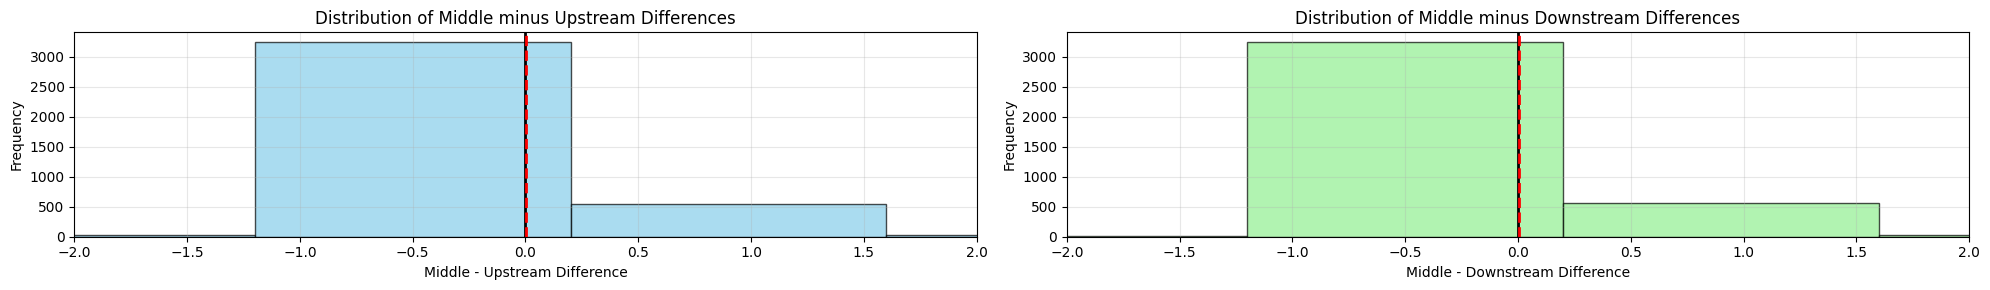

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file (assuming it's tab-separated)
df = pd.read_csv('/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_TSS_mapped_coded_count_per_gene.txt', sep='\t')

# Calculate the differences
df['Middle_minus_Upstream'] = df['Middle_count (450-550)'] - df['Upstream_count (200-300)']
df['Middle_minus_Downstream'] = df['Middle_count (450-550)'] - df['Downstream_count (700-800)']

# Display the data with calculated differences
print("Data with calculated differences:")
print(df[['Gene_code', 'Middle_minus_Upstream', 'Middle_minus_Downstream']])
print("\n")

# Print summary statistics
print("Summary statistics for Middle - Upstream:")
print(df['Middle_minus_Upstream'].describe())
print("\nSummary statistics for Middle - Downstream:")
print(df['Middle_minus_Downstream'].describe())

# MANUALLY SPECIFY THE MEAN VALUES (change these as needed)
manual_mean_upstream = 3.99233E-03  # Change this to your desired mean for Middle - Upstream
manual_mean_downstream = 5.72813E-03  # Change this to your desired mean for Middle - Downstream

# MANUALLY SPECIFY X-AXIS LIMITS (change these as needed)
x_min = -2  # Change this to your desired minimum x-value
x_max = 2   # Change this to your desired maximum x-value
x_lim = (x_min, x_max)

# Create distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

# Calculate bin edges that work for both distributions
all_differences = pd.concat([df['Middle_minus_Upstream'], df['Middle_minus_Downstream']])
bins = np.linspace(all_differences.min(), all_differences.max(), 6)

# Plot 1: Middle - Upstream distribution
ax1.hist(df['Middle_minus_Upstream'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax1.axvline(manual_mean_upstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_upstream:.3f}')
ax1.set_xlabel('Middle - Upstream Difference')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Middle minus Upstream Differences')
ax1.set_xlim(x_lim)  # Set x-axis limits
#ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Middle - Downstream distribution
ax2.hist(df['Middle_minus_Downstream'], bins=bins, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax2.axvline(manual_mean_downstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_downstream:.3f}')
ax2.set_xlabel('Middle - Downstream Difference')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Middle minus Downstream Differences')
ax2.set_xlim(x_lim)  # Set x-axis limits
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/alexpalazzo1/Documents/Tina/DNM/Decode/All_PCG_difference_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### lncRNA

Data with calculated differences:
      Gene_code  Middle_minus_Upstream  Middle_minus_Downstream
0             1                   0.27                     0.34
1             2                   0.08                     0.03
2             3                   0.04                     0.09
3             4                  -0.14                    -0.13
4             5                  -0.03                     0.25
...         ...                    ...                      ...
4234       4253                   0.01                    -0.13
4235       4254                   0.10                     0.17
4236       4255                   0.00                     0.00
4237       4256                  -0.07                    -0.10
4238       4257                   0.02                     0.11

[4239 rows x 3 columns]


Summary statistics for Middle - Upstream:
count    4239.000000
mean        0.055973
std         0.135743
min        -0.850000
25%        -0.020000
50%         0.030000
75%

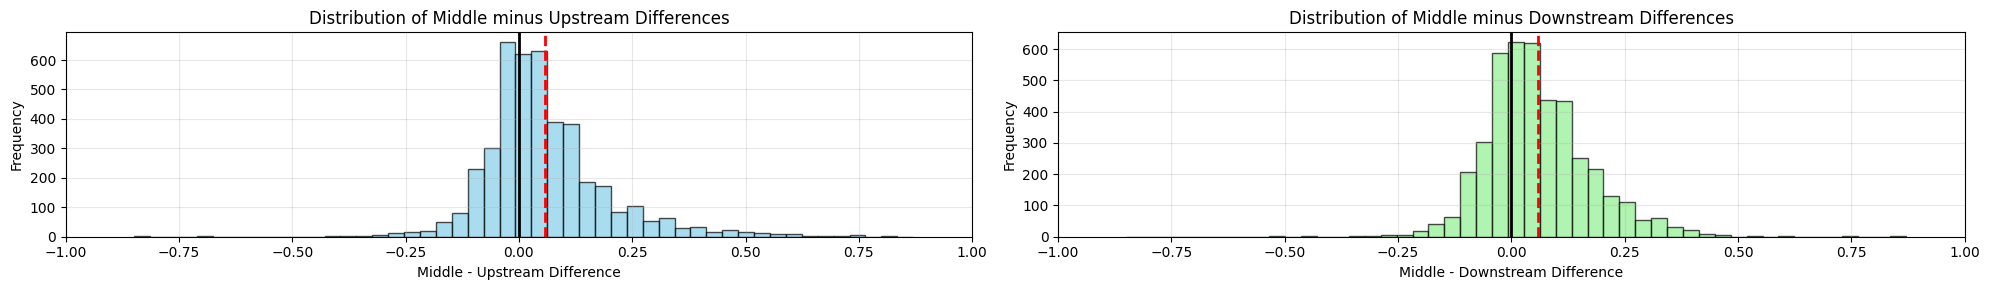

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file (assuming it's tab-separated)
df = pd.read_csv('rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38_coded_count_per_gene.txt', sep='\t')

# Calculate the differences
df['Middle_minus_Upstream'] = df['Middle_count (450-550)'] - df['Upstream_count (200-300)']
df['Middle_minus_Downstream'] = df['Middle_count (450-550)'] - df['Downstream_count (700-800)']

# Display the data with calculated differences
print("Data with calculated differences:")
print(df[['Gene_code', 'Middle_minus_Upstream', 'Middle_minus_Downstream']])
print("\n")

# Print summary statistics
print("Summary statistics for Middle - Upstream:")
print(df['Middle_minus_Upstream'].describe())
print("\nSummary statistics for Middle - Downstream:")
print(df['Middle_minus_Downstream'].describe())

# MANUALLY SPECIFY THE MEAN VALUES (change these as needed)
manual_mean_upstream = 0.056607986  # Change this to your desired mean for Middle - Upstream
manual_mean_downstream = 0.057819735  # Change this to your desired mean for Middle - Downstream

# MANUALLY SPECIFY X-AXIS LIMITS (change these as needed)
x_min = -1  # Change this to your desired minimum x-value
x_max = 1   # Change this to your desired maximum x-value
x_lim = (x_min, x_max)

# Create distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

# Calculate bin edges that work for both distributions
all_differences = pd.concat([df['Middle_minus_Upstream'], df['Middle_minus_Downstream']])
bins = np.linspace(all_differences.min(), all_differences.max(), 50)

# Plot 1: Middle - Upstream distribution
ax1.hist(df['Middle_minus_Upstream'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax1.axvline(manual_mean_upstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_upstream:.3f}')
ax1.set_xlabel('Middle - Upstream Difference')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Middle minus Upstream Differences')
ax1.set_xlim(x_lim)  # Set x-axis limits
#ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Middle - Downstream distribution
ax2.hist(df['Middle_minus_Downstream'], bins=bins, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax2.axvline(manual_mean_downstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_downstream:.3f}')
ax2.set_xlabel('Middle - Downstream Difference')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Middle minus Downstream Differences')
ax2.set_xlim(x_lim)  # Set x-axis limits
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lncRNA_difference_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### No express

Data with calculated differences:
     Gene_code  Middle_minus_Upstream  Middle_minus_Downstream
0            1                   0.04                     0.08
1            2                  -0.01                    -0.02
2            3                   0.05                     0.03
3            4                  -0.01                     0.02
4            5                  -0.10                    -0.05
..         ...                    ...                      ...
847        872                  -0.13                    -0.02
848        873                   0.03                     0.02
849        874                  -0.02                     0.06
850        875                   0.05                     0.02
851        876                  -0.01                     0.02

[852 rows x 3 columns]


Summary statistics for Middle - Upstream:
count    852.000000
mean       0.003415
std        0.082038
min       -0.410000
25%       -0.040000
50%        0.000000
75%        0.050000
ma

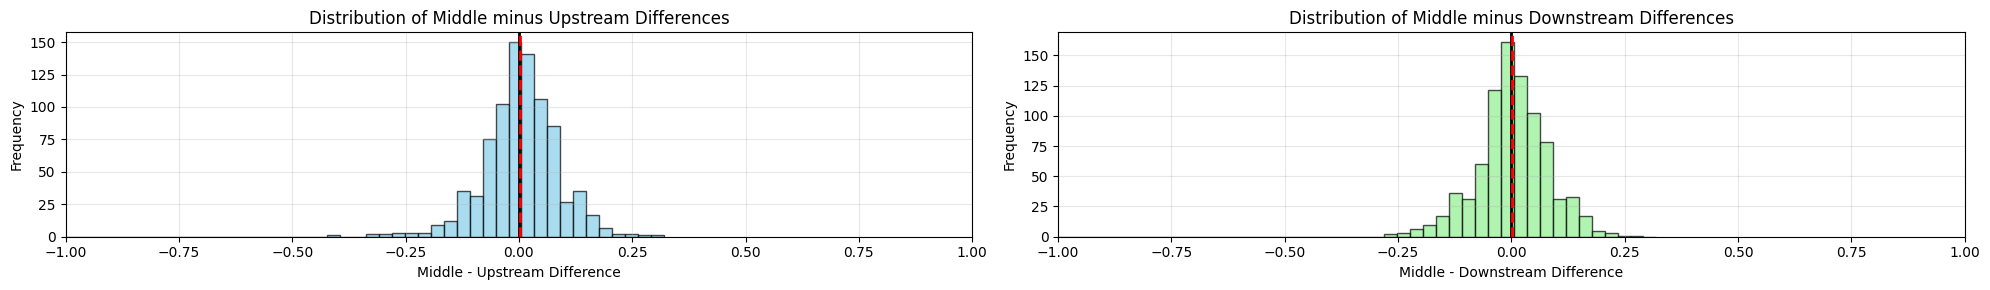

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file (assuming it's tab-separated)
df = pd.read_csv('rareSNP_mapped_TSS_rare_tpm0_noCAGE_coded_count_per_gene.txt', sep='\t')

# Calculate the differences
df['Middle_minus_Upstream'] = df['Middle_count (450-550)'] - df['Upstream_count (200-300)']
df['Middle_minus_Downstream'] = df['Middle_count (450-550)'] - df['Downstream_count (700-800)']

# Display the data with calculated differences
print("Data with calculated differences:")
print(df[['Gene_code', 'Middle_minus_Upstream', 'Middle_minus_Downstream']])
print("\n")

# Print summary statistics
print("Summary statistics for Middle - Upstream:")
print(df['Middle_minus_Upstream'].describe())
print("\nSummary statistics for Middle - Downstream:")
print(df['Middle_minus_Downstream'].describe())

# MANUALLY SPECIFY THE MEAN VALUES (change these as needed)
manual_mean_upstream = 0.003289028  # Change this to your desired mean for Middle - Upstream
manual_mean_downstream = 0.000915503  # Change this to your desired mean for Middle - Downstream

# MANUALLY SPECIFY X-AXIS LIMITS (change these as needed)
x_min = -1  # Change this to your desired minimum x-value
x_max = 1   # Change this to your desired maximum x-value
x_lim = (x_min, x_max)

# Create distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

# Calculate bin edges that work for both distributions
all_differences = pd.concat([df['Middle_minus_Upstream'], df['Middle_minus_Downstream']])
bins = np.linspace(all_differences.min(), all_differences.max(), 50)

# Plot 1: Middle - Upstream distribution
ax1.hist(df['Middle_minus_Upstream'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax1.axvline(manual_mean_upstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_upstream:.3f}')
ax1.set_xlabel('Middle - Upstream Difference')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Middle minus Upstream Differences')
ax1.set_xlim(x_lim)  # Set x-axis limits
#ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Middle - Downstream distribution
ax2.hist(df['Middle_minus_Downstream'], bins=bins, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax2.axvline(manual_mean_downstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_downstream:.3f}')
ax2.set_xlabel('Middle - Downstream Difference')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Middle minus Downstream Differences')
ax2.set_xlim(x_lim)  # Set x-axis limits
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('noexpress_difference_distributions.png', dpi=300, bbox_inches='tight')
plt.show()



### Intergenic random

Data with calculated differences:
       Gene_code  Middle_minus_Upstream  Middle_minus_Downstream
0              1                   0.10                    -0.01
1              2                   0.02                    -0.09
2              3                  -0.08                    -0.08
3              4                  -0.03                     0.00
4              5                   0.05                    -0.05
...          ...                    ...                      ...
13102      14996                   0.02                     0.03
13103      14997                   0.07                     0.07
13104      14998                   0.03                     0.04
13105      14999                  -0.03                    -0.04
13106      15000                   0.08                     0.10

[13107 rows x 3 columns]


Summary statistics for Middle - Upstream:
count    13107.000000
mean        -0.000446
std          0.070909
min         -0.520000
25%         -0.040000
50%   

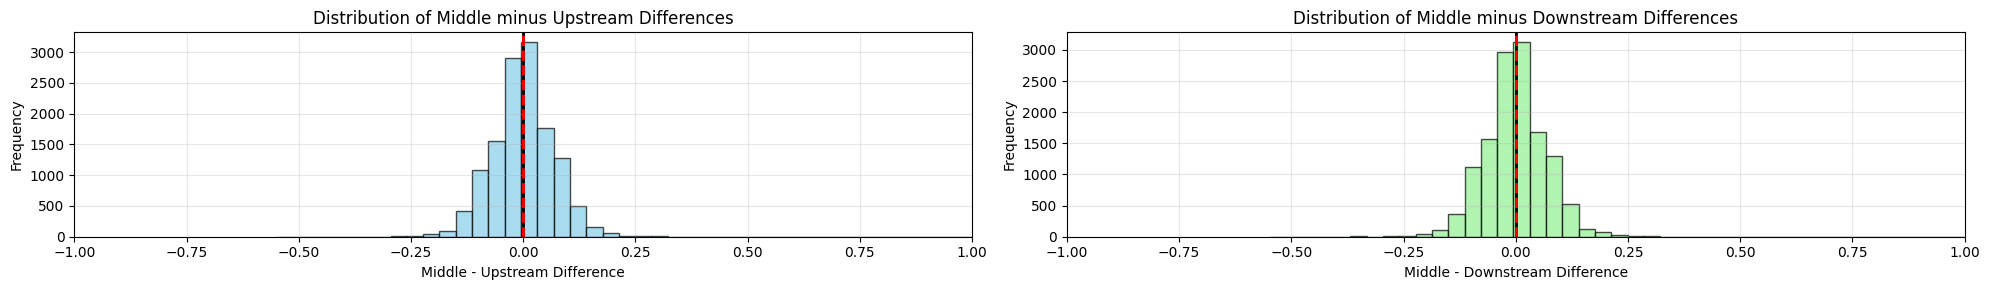

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file (assuming it's tab-separated)
df = pd.read_csv('rareSNP_mapped_intergenic_random_rare_coded_count_per_gene.txt', sep='\t')

# Calculate the differences
df['Middle_minus_Upstream'] = df['Middle_count (450-550)'] - df['Upstream_count (200-300)']
df['Middle_minus_Downstream'] = df['Middle_count (450-550)'] - df['Downstream_count (700-800)']

# Display the data with calculated differences
print("Data with calculated differences:")
print(df[['Gene_code', 'Middle_minus_Upstream', 'Middle_minus_Downstream']])
print("\n")

# Print summary statistics
print("Summary statistics for Middle - Upstream:")
print(df['Middle_minus_Upstream'].describe())
print("\nSummary statistics for Middle - Downstream:")
print(df['Middle_minus_Downstream'].describe())

# MANUALLY SPECIFY THE MEAN VALUES (change these as needed)
manual_mean_upstream = 0.000385479  # Change this to your desired mean for Middle - Upstream
manual_mean_downstream = 0.000160396  # Change this to your desired mean for Middle - Downstream

# MANUALLY SPECIFY X-AXIS LIMITS (change these as needed)
x_min = -1  # Change this to your desired minimum x-value
x_max = 1   # Change this to your desired maximum x-value
x_lim = (x_min, x_max)

# Create distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

# Calculate bin edges that work for both distributions
all_differences = pd.concat([df['Middle_minus_Upstream'], df['Middle_minus_Downstream']])
bins = np.linspace(all_differences.min(), all_differences.max(), 50)

# Plot 1: Middle - Upstream distribution
ax1.hist(df['Middle_minus_Upstream'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax1.axvline(manual_mean_upstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_upstream:.3f}')
ax1.set_xlabel('Middle - Upstream Difference')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Middle minus Upstream Differences')
ax1.set_xlim(x_lim)  # Set x-axis limits
#ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Middle - Downstream distribution
ax2.hist(df['Middle_minus_Downstream'], bins=bins, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax2.axvline(manual_mean_downstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_downstream:.3f}')
ax2.set_xlabel('Middle - Downstream Difference')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Middle minus Downstream Differences')
ax2.set_xlim(x_lim)  # Set x-axis limits
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('intergenic_random_difference_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### RNAPII Intergenic

Data with calculated differences:
      Gene_code  Middle_minus_Upstream  Middle_minus_Downstream
0             1                  -0.01                    -0.03
1             2                   0.03                    -0.09
2             3                  -0.09                    -0.09
3             4                  -0.02                    -0.07
4             5                   0.29                     0.40
...         ...                    ...                      ...
1047       1071                   0.00                    -0.04
1048       1072                   0.10                     0.20
1049       1073                   0.24                     0.35
1050       1074                   0.04                    -0.07
1051       1076                  -0.01                    -0.02

[1052 rows x 3 columns]


Summary statistics for Middle - Upstream:
count    1052.000000
mean        0.100932
std         0.225053
min        -1.760000
25%        -0.010000
50%         0.060000
75%

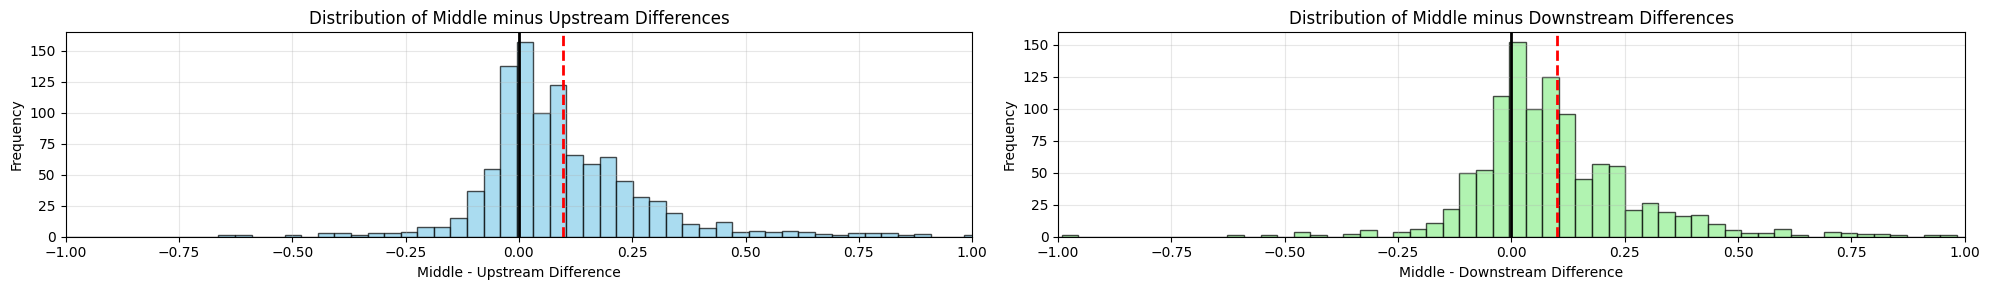

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file (assuming it's tab-separated)
df = pd.read_csv('rareSNP_mapped_RNAPII_human_testes_thresholded_intergenic_coded_count_per_gene.txt', sep='\t')

# Calculate the differences
df['Middle_minus_Upstream'] = df['Middle_count (450-550)'] - df['Upstream_count (200-300)']
df['Middle_minus_Downstream'] = df['Middle_count (450-550)'] - df['Downstream_count (700-800)']

# Display the data with calculated differences
print("Data with calculated differences:")
print(df[['Gene_code', 'Middle_minus_Upstream', 'Middle_minus_Downstream']])
print("\n")

# Print summary statistics
print("Summary statistics for Middle - Upstream:")
print(df['Middle_minus_Upstream'].describe())
print("\nSummary statistics for Middle - Downstream:")
print(df['Middle_minus_Downstream'].describe())

# MANUALLY SPECIFY THE MEAN VALUES (change these as needed)
manual_mean_upstream = 0.097823989  # Change this to your desired mean for Middle - Upstream
manual_mean_downstream = 0.100278552  # Change this to your desired mean for Middle - Downstream

# MANUALLY SPECIFY X-AXIS LIMITS (change these as needed)
x_min = -1  # Change this to your desired minimum x-value
x_max = 1   # Change this to your desired maximum x-value
x_lim = (x_min, x_max)

# Create distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 3))

# Calculate bin edges that work for both distributions
all_differences = pd.concat([df['Middle_minus_Upstream'], df['Middle_minus_Downstream']])
bins = np.linspace(all_differences.min(), all_differences.max(), 100)

# Plot 1: Middle - Upstream distribution
ax1.hist(df['Middle_minus_Upstream'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax1.axvline(manual_mean_upstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_upstream:.3f}')
ax1.set_xlabel('Middle - Upstream Difference')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Middle minus Upstream Differences')
ax1.set_xlim(x_lim)  # Set x-axis limits
#ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Middle - Downstream distribution
ax2.hist(df['Middle_minus_Downstream'], bins=bins, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='x=0')  # Black line at x=0
ax2.axvline(manual_mean_downstream, color='red', linestyle='--', linewidth=2,
           label=f'Manual Mean: {manual_mean_downstream:.3f}')
ax2.set_xlabel('Middle - Downstream Difference')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Middle minus Downstream Differences')
ax2.set_xlim(x_lim)  # Set x-axis limits
#ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('RNAPII_intergenic_difference_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

---
# II. Permutation test
To test if mutation rate of one locus of a dataset is significantly different from one locus of another dataset.

## a. For decode DNM

Raw data statistics:
File 1 raw: 2375 values, mean: 0.24589473684211
File 2 raw: 2580 values, mean: 0.24457364341085

Normalized data statistics:
File 1 normalized: mean: 1.13420081569237e-07
File 2 normalized: mean: 1.12810721130467e-07

Actual difference in means (File1 - File2): 6.09360438769603e-10
Permutation test results:
  Mean of permutation differences: -1.01564840617809e-10
  Standard deviation of permutation differences: 6.03665429481935e-09
Permutation results saved to: /home/alexpalazzo1/Documents/Tina/DNM/Decode/lncRNA_noexpress_vs_intergenic_permutation_results.txt
  p-value: 0.90909090909091


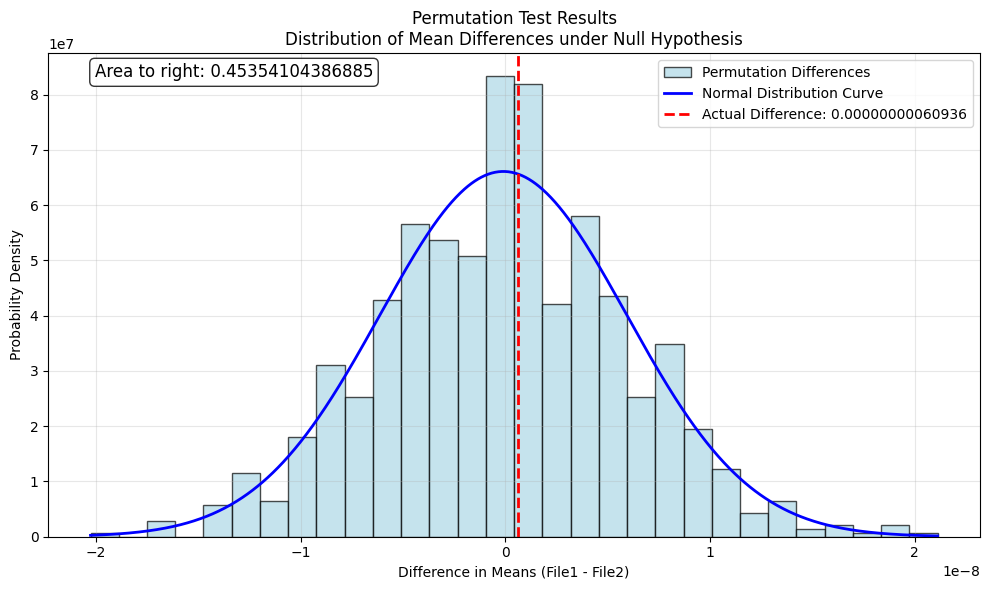

Area under curve to right of actual difference: 0.45354104386885


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

def read_third_column(filename):
    """Read the third column from a file, skipping the header"""
    data = []
    with open(filename, 'r') as f:
        # Skip header line
        next(f)
        for line in f:
            columns = line.strip().split()
            if len(columns) >= 3:
                try:
                    data.append(float(columns[2]))
                except ValueError:
                    continue
    return np.array(data)

def normalize_data1(data):
    """Normalize data1: each value / 200 / 1077 / 5420 / 2"""
    return data / 200 / 5420 / 2

def normalize_data2(data):
    """Normalize data2: each value / 200 / 15000 / 5420 / 2"""
    return data / 200 / 5420 / 2

def permutation_test(data1, data2, n_permutations=1000):
    """Perform permutation test between two datasets"""
    # Combine the data
    combined_data = np.concatenate([data1, data2])
    n1 = len(data1)
    n_total = len(combined_data)
    
    # Calculate the actual difference in means
    actual_diff = np.mean(data1) - np.mean(data2)
    
    # Perform permutations
    permutation_diffs = []
    
    for _ in range(n_permutations):
        # Shuffle the combined data
        np.random.shuffle(combined_data)
        
        # Split into two groups
        group_a = combined_data[:n1]
        group_b = combined_data[n1:]
        
        # Calculate difference in means
        diff = np.mean(group_a) - np.mean(group_b)
        permutation_diffs.append(diff)
    
    return actual_diff, np.array(permutation_diffs)

def save_permutation_results(permutation_diffs, actual_diff, filename="lncRNA_noexpress_vs_intergenic_permutation_results.txt"):
    """Save permutation test results to a file"""
    with open(filename, 'w') as f:
        f.write("Permutation Test Results\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Actual difference in means: {actual_diff:.14f}\n")
        f.write(f"Number of permutations: {len(permutation_diffs)}\n")
        f.write(f"Mean of permutation differences: {np.mean(permutation_diffs):.14f}\n")
        f.write(f"Standard deviation of permutation differences: {np.std(permutation_diffs):.14f}\n")
        f.write(f"Minimum permutation difference: {np.min(permutation_diffs):.14f}\n")
        f.write(f"Maximum permutation difference: {np.max(permutation_diffs):.14f}\n")
        
        # Calculate p-value (two-tailed test)
        extreme_count = np.sum(np.abs(permutation_diffs) >= np.abs(actual_diff))
        p_value = (extreme_count + 1) / (len(permutation_diffs) + 1)
        f.write(f"p-value: {p_value:.14f}\n\n")
        
        f.write("All permutation differences:\n")
        f.write("Index\tDifference\n")
        f.write("-" * 20 + "\n")
        for i, diff in enumerate(permutation_diffs):
            f.write(f"{i+1}\t{diff:.14f}\n")
    
    print(f"Permutation results saved to: {filename}")
    return p_value

def plot_permutation_results(permutation_diffs, actual_diff):
    """Plot the permutation test results with normal distribution curve"""
    # Convert the data to a NumPy array
    data_array = permutation_diffs
    
    # Calculate mean and standard deviation
    mean_value = np.mean(data_array)
    std_dev = np.std(data_array)
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of permutation differences
    plt.hist(data_array, bins=30, density=True, alpha=0.7, 
             color='lightblue', edgecolor='black', label='Permutation Differences')
    
    # Create a normal distribution with mean and standard deviation
    x = np.linspace(min(data_array), max(data_array), 1000)
    y = norm.pdf(x, mean_value, std_dev)
    
    # Plot the normal distribution curve
    plt.plot(x, y, 'b-', linewidth=2, label='Normal Distribution Curve')
    
    # Set up the vertical line for actual difference
    plt.axvline(x=actual_diff, color='r', linestyle='--', 
                linewidth=2, label=f'Actual Difference: {actual_diff:.14f}')
    
    # Calculate the area under the curve to the left of the vertical line
    area, _ = quad(lambda x: norm.pdf(x, mean_value, std_dev), 
                  min(data_array), actual_diff)
    
    # Display the result on the plot
    plt.text(0.05, 0.95, f'Area to right: {1-area:.14f}', 
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add plot details
    plt.legend()
    plt.title('Permutation Test Results\nDistribution of Mean Differences under Null Hypothesis')
    plt.xlabel('Difference in Means (File1 - File2)')
    plt.ylabel('Probability Density')
    plt.grid(True, alpha=0.3)
    
    # Show the plot
    plt.tight_layout()
    plt.show()
    
    return area

def main():
    # Read the two files (replace with your actual filenames)
    file1 = "/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_lncRNA_noexpress_mapped_noindel_coded_count_per_gene_200.txt"
    file2 = "/home/alexpalazzo1/Documents/Tina/DNM/Decode/decode_dnm_GRCh38_random_intergenic_mapped_noindel_coded_count_per_gene_200.txt"
    
    # Read third columns
    raw_data1 = read_third_column(file1)
    raw_data2 = read_third_column(file2)
    
    # Apply normalization
    data1 = normalize_data1(raw_data1)
    data2 = normalize_data2(raw_data2)
    
    print("Raw data statistics:")
    print(f"File 1 raw: {len(raw_data1)} values, mean: {np.mean(raw_data1):.14f}")
    print(f"File 2 raw: {len(raw_data2)} values, mean: {np.mean(raw_data2):.14f}")
    
    print("\nNormalized data statistics:")
    print(f"File 1 normalized: mean: {np.mean(data1):.14e}")
    print(f"File 2 normalized: mean: {np.mean(data2):.14e}")
    
    # Perform permutation test
    actual_diff, permutation_diffs = permutation_test(data1, data2, n_permutations=1000)
    
    print(f"\nActual difference in means (File1 - File2): {actual_diff:.14e}")
    print(f"Permutation test results:")
    print(f"  Mean of permutation differences: {np.mean(permutation_diffs):.14e}")
    print(f"  Standard deviation of permutation differences: {np.std(permutation_diffs):.14e}")
    
    # Save permutation results to file
    p_value = save_permutation_results(permutation_diffs, actual_diff, "/home/alexpalazzo1/Documents/Tina/DNM/Decode/lncRNA_noexpress_vs_intergenic_permutation_results.txt")
    
    print(f"  p-value: {p_value:.14f}")
    
    # Plot the results
    area_left = plot_permutation_results(permutation_diffs, actual_diff)
    print(f"Area under curve to right of actual difference: {1-area_left:.14f}")
    
    return permutation_diffs, actual_diff, data1, data2

if __name__ == "__main__":
    permutation_results, actual_diff_value, normalized_data1, normalized_data2 = main()

## b. For rare SNP

Raw data statistics:
File 1 raw: 12548 values, mean: 0.00000003053307
File 2 raw: 13107 values, mean: 0.00000002921410

Normalized data statistics:
File 1 normalized: mean: 3.05330738021027e-08
File 2 normalized: mean: 2.92140969485513e-08

Actual difference in means (File1 - File2): 1.31897685355140e-09
Permutation test results:
  Mean of permutation differences: -3.48890539556682e-11
  Standard deviation of permutation differences: 1.15126271905580e-09
Permutation results saved to: /home/alexpalazzo1/Documents/Tina/Rare_SNP/lncRNA_noexpress_vs_intergenic_permutation_results.txt
  p-value: 0.30469530469530


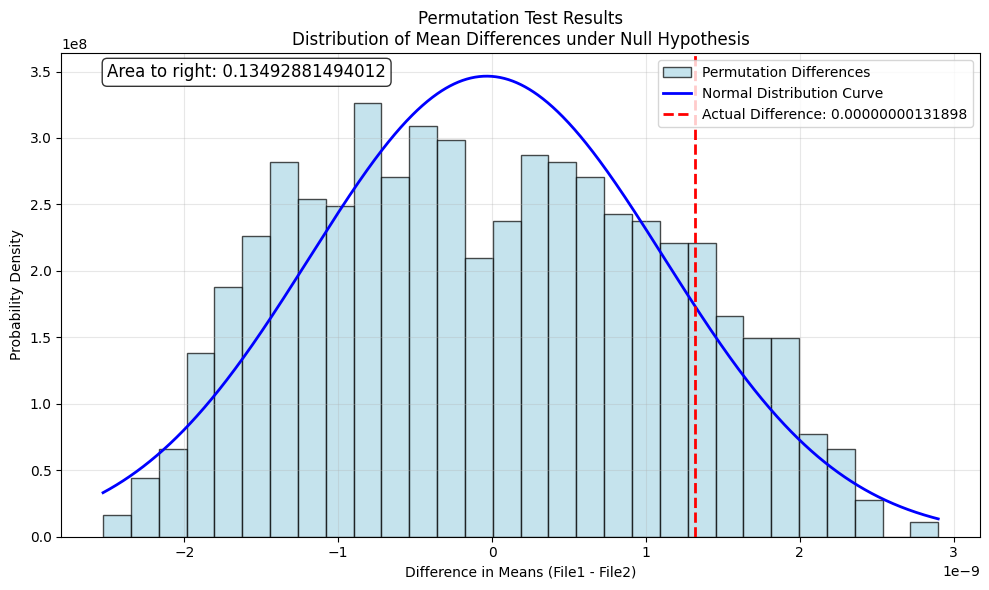

Area under curve to right of actual difference: 0.13492881494012


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

def read_third_column(filename):
    """Read the third column from a file, skipping the header"""
    data = []
    with open(filename, 'r') as f:
        # Skip header line
        next(f)
        for line in f:
            columns = line.strip().split()
            if len(columns) >= 3:
                try:
                    data.append(float(columns[2]))
                except ValueError:
                    continue
    return np.array(data)

def normalize_data1(data):
    """Normalize data1: each value / 200 / 1077 / 5420 / 2"""
    return data

def normalize_data2(data):
    """Normalize data2: each value / 200 / 15000 / 5420 / 2"""
    return data

def permutation_test(data1, data2, n_permutations=1000):
    """Perform permutation test between two datasets"""
    # Combine the data
    combined_data = np.concatenate([data1, data2])
    n1 = len(data1)
    n_total = len(combined_data)
    
    # Calculate the actual difference in means
    actual_diff = np.mean(data1) - np.mean(data2)
    
    # Perform permutations
    permutation_diffs = []
    
    for _ in range(n_permutations):
        # Shuffle the combined data
        np.random.shuffle(combined_data)
        
        # Split into two groups
        group_a = combined_data[:n1]
        group_b = combined_data[n1:]
        
        # Calculate difference in means
        diff = np.mean(group_a) - np.mean(group_b)
        permutation_diffs.append(diff)
    
    return actual_diff, np.array(permutation_diffs)

def save_permutation_results(permutation_diffs, actual_diff, filename="lncRNA_noexpress_vs_intergenic_permutation_results.txt"):
    """Save permutation test results to a file"""
    with open(filename, 'w') as f:
        f.write("Permutation Test Results\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Actual difference in means: {actual_diff:.14f}\n")
        f.write(f"Number of permutations: {len(permutation_diffs)}\n")
        f.write(f"Mean of permutation differences: {np.mean(permutation_diffs):.14f}\n")
        f.write(f"Standard deviation of permutation differences: {np.std(permutation_diffs):.14f}\n")
        f.write(f"Minimum permutation difference: {np.min(permutation_diffs):.14f}\n")
        f.write(f"Maximum permutation difference: {np.max(permutation_diffs):.14f}\n")
        
        # Calculate p-value (two-tailed test)
        extreme_count = np.sum(np.abs(permutation_diffs) >= np.abs(actual_diff))
        p_value = (extreme_count + 1) / (len(permutation_diffs) + 1)
        f.write(f"p-value: {p_value:.14f}\n\n")
        
        f.write("All permutation differences:\n")
        f.write("Index\tDifference\n")
        f.write("-" * 20 + "\n")
        for i, diff in enumerate(permutation_diffs):
            f.write(f"{i+1}\t{diff:.14f}\n")
    
    print(f"Permutation results saved to: {filename}")
    return p_value

def plot_permutation_results(permutation_diffs, actual_diff):
    """Plot the permutation test results with normal distribution curve"""
    # Convert the data to a NumPy array
    data_array = permutation_diffs
    
    # Calculate mean and standard deviation
    mean_value = np.mean(data_array)
    std_dev = np.std(data_array)
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of permutation differences
    plt.hist(data_array, bins=30, density=True, alpha=0.7, 
             color='lightblue', edgecolor='black', label='Permutation Differences')
    
    # Create a normal distribution with mean and standard deviation
    x = np.linspace(min(data_array), max(data_array), 1000)
    y = norm.pdf(x, mean_value, std_dev)
    
    # Plot the normal distribution curve
    plt.plot(x, y, 'b-', linewidth=2, label='Normal Distribution Curve')
    
    # Set up the vertical line for actual difference
    plt.axvline(x=actual_diff, color='r', linestyle='--', 
                linewidth=2, label=f'Actual Difference: {actual_diff:.14f}')
    
    # Calculate the area under the curve to the left of the vertical line
    area, _ = quad(lambda x: norm.pdf(x, mean_value, std_dev), 
                  min(data_array), actual_diff)
    
    # Display the result on the plot
    plt.text(0.05, 0.95, f'Area to right: {1-area:.14f}', 
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add plot details
    plt.legend()
    plt.title('Permutation Test Results\nDistribution of Mean Differences under Null Hypothesis')
    plt.xlabel('Difference in Means (File1 - File2)')
    plt.ylabel('Probability Density')
    plt.grid(True, alpha=0.3)
    
    # Show the plot
    plt.tight_layout()
    plt.show()
    
    return area

def main():
    # Read the two files (replace with your actual filenames)
    file1 = "/home/alexpalazzo1/Documents/Tina/Rare_SNP/rareSNP_mapped_lncrna_non_testis_strand_complement_coded_count_per_gene_correct.txt"
    file2 = "/home/alexpalazzo1/Documents/Tina/Rare_SNP/rareSNP_mapped_intergenic_random_rare_coded_count_per_gene_correct.txt"
    
    # Read third columns
    raw_data1 = read_third_column(file1)
    raw_data2 = read_third_column(file2)
    
    # Apply normalization
    data1 = normalize_data1(raw_data1)
    data2 = normalize_data2(raw_data2)
    
    print("Raw data statistics:")
    print(f"File 1 raw: {len(raw_data1)} values, mean: {np.mean(raw_data1):.14f}")
    print(f"File 2 raw: {len(raw_data2)} values, mean: {np.mean(raw_data2):.14f}")
    
    print("\nNormalized data statistics:")
    print(f"File 1 normalized: mean: {np.mean(data1):.14e}")
    print(f"File 2 normalized: mean: {np.mean(data2):.14e}")
    
    # Perform permutation test
    actual_diff, permutation_diffs = permutation_test(data1, data2, n_permutations=1000)
    
    print(f"\nActual difference in means (File1 - File2): {actual_diff:.14e}")
    print(f"Permutation test results:")
    print(f"  Mean of permutation differences: {np.mean(permutation_diffs):.14e}")
    print(f"  Standard deviation of permutation differences: {np.std(permutation_diffs):.14e}")
    
    # Save permutation results to file
    p_value = save_permutation_results(permutation_diffs, actual_diff, "/home/alexpalazzo1/Documents/Tina/Rare_SNP/lncRNA_noexpress_vs_intergenic_permutation_results.txt")
    
    print(f"  p-value: {p_value:.14f}")
    
    # Plot the results
    area_left = plot_permutation_results(permutation_diffs, actual_diff)
    print(f"Area under curve to right of actual difference: {1-area_left:.14f}")
    
    return permutation_diffs, actual_diff, data1, data2

if __name__ == "__main__":
    permutation_results, actual_diff_value, normalized_data1, normalized_data2 = main()

## c. Graph permuation test distribution

### For rare SNP

Using manual values:
All protein coding genes: 2.6007e-08
lncRNA expressed in testes: 1.76651e-08
Protein coding genes not expressed in testes: 3.148e-09
lncRNA not expressed in testes: 4.72891e-09
Intergenic RNAPII pause sites: 3.24234e-08


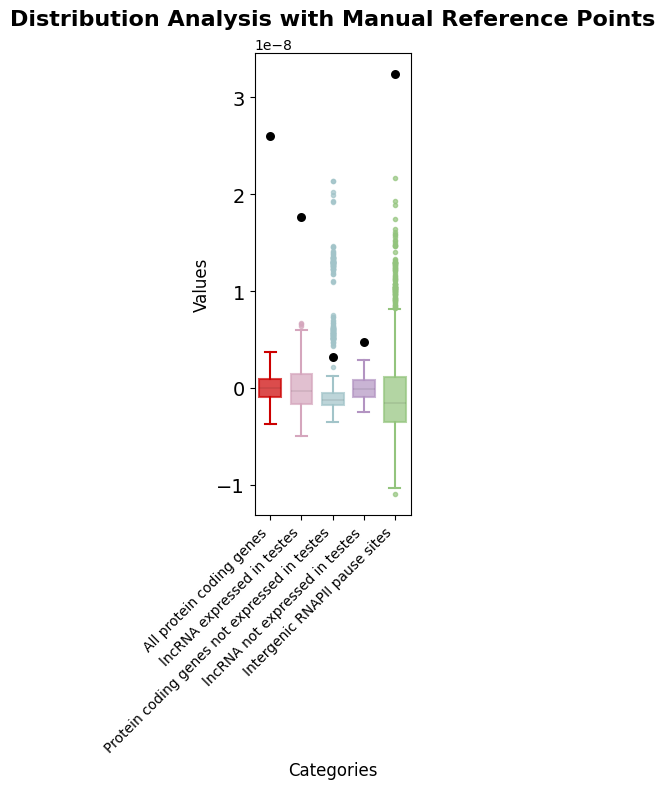


COMPARATIVE ANALYSIS

All protein coding genes:
  Manual value: 0.000000
  Median: 0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

lncRNA expressed in testes:
  Manual value: 0.000000
  Median: -0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

Protein coding genes not expressed in testes:
  Manual value: 0.000000
  Median: -0.000000
  Q1: -0.000000, Q3: -0.000000
  Manual value is above median

lncRNA not expressed in testes:
  Manual value: 0.000000
  Median: -0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

Intergenic RNAPII pause sites:
  Manual value: 0.000000
  Median: -0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file
df = pd.read_csv('Permutation_vs_intergenic_newrate_correct.csv', sep=',')

# Manually specify values - EDIT THESE NUMBERS
manual_values = {
    'All protein coding genes': 2.6007E-08,      # Change this value
    'lncRNA expressed in testes': 1.76651E-08,      # Change this value  
    'Protein coding genes not expressed in testes': 3.14800E-09,   # Change this value
    'lncRNA not expressed in testes': 4.72891E-09,
    'Intergenic RNAPII pause sites': 3.24234E-08       # Change this value
}

print("Using manual values:")
for col, value in manual_values.items():
    print(f"{col}: {value}")

# Create the plot with more customization
fig, ax = plt.subplots(figsize=(3, 8))

# Colors for boxes (same colors for fill and outline)
colors = ['#cc0000', '#d5a6bd', '#a2c4c9', '#b394c2','#93c47d']

# Create individual box plots for each column to customize outliers
for i, (col, color) in enumerate(zip(df.columns, colors)):
    # Create boxplot for this column only
    box_plot = ax.boxplot([df[col]], 
                          positions=[i+1],
                          widths=0.7,
                          patch_artist=True,
                          boxprops=dict(linestyle='-', linewidth=1.5),
                          whiskerprops=dict(linestyle='-', linewidth=1.5, color=color),
                          capprops=dict(linestyle='-', linewidth=1.5, color=color),
                          medianprops=dict(linestyle='-', linewidth=0.1, color='black'),
                          flierprops=dict(marker='o', markersize=3, markerfacecolor=color, 
                                        markeredgecolor=color, alpha=0.7))  # Same color outliers
    
    # Apply color to the box
    for patch in box_plot['boxes']:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.7)

# Add manual values as red dots (no label)
for i, col in enumerate(df.columns):
    x_position = i + 1
    y_value = manual_values[col]
    ax.scatter(x_position, y_value, s=20, c='black', marker='o',
               edgecolors='black', linewidth=2, zorder=3)

# Set x-axis labels and limits
ax.set_xticks(range(1, len(df.columns) + 1))
ax.set_xticklabels(df.columns)
ax.set_xlim(0.5, len(df.columns) + 0.5)

# Customize the plot
ax.set_title('Distribution Analysis with Manual Reference Points', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Categories', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
#ax.grid(True, alpha=0.3, axis='y')

# Increase size of y-axis numbers
ax.tick_params(axis='y', which='major', labelsize=14)  # Increase y-axis tick label size

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save the plot as a figure
plt.savefig('boxplot_analysis.png', dpi=300, bbox_inches='tight')

plt.show()

# Print comparative statistics
print("\n" + "="*50)
print("COMPARATIVE ANALYSIS")
print("="*50)
for col in df.columns:
    manual_val = manual_values[col]
    col_data = df[col]
    q1, median, q3 = col_data.quantile([0.25, 0.5, 0.75])
    
    print(f"\n{col}:")
    print(f"  Manual value: {manual_val:.6f}")
    print(f"  Median: {median:.6f}")
    print(f"  Q1: {q1:.6f}, Q3: {q3:.6f}")
    print(f"  Manual value is {('below' if manual_val < median else 'above')} median")

### For DNM decode

Using manual values:
All protein coding genes: 1.874942e-08
lncRNA expressed in testes: 1.890366e-08
Protein coding genes not expressed in testes: 1.17749e-09
lncRNA not expressed in testes: 6.0936e-10
Intergenic RNAPII pause sites: 7.632297e-08


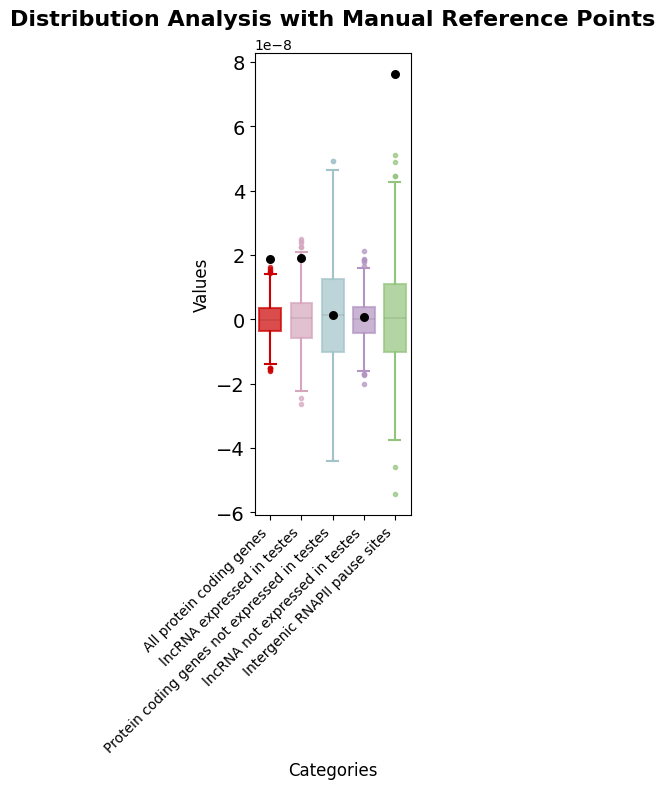


COMPARATIVE ANALYSIS

All protein coding genes:
  Manual value: 0.000000
  Median: -0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

lncRNA expressed in testes:
  Manual value: 0.000000
  Median: 0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

Protein coding genes not expressed in testes:
  Manual value: 0.000000
  Median: 0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

lncRNA not expressed in testes:
  Manual value: 0.000000
  Median: 0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median

Intergenic RNAPII pause sites:
  Manual value: 0.000000
  Median: 0.000000
  Q1: -0.000000, Q3: 0.000000
  Manual value is above median


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file
df = pd.read_csv('/home/alexpalazzo1/Documents/Tina/DNM/Decode/Permutation_vs_intergenic_newrate.csv', sep=',')

# Manually specify values - EDIT THESE NUMBERS
manual_values = {
    'All protein coding genes': 0.00000001874942,      # Change this value
    'lncRNA expressed in testes': 0.00000001890366,      # Change this value  
    'Protein coding genes not expressed in testes': 0.00000000117749,   # Change this value
    'lncRNA not expressed in testes': 0.00000000060936,
    'Intergenic RNAPII pause sites': 0.00000007632297       # Change this value
}

print("Using manual values:")
for col, value in manual_values.items():
    print(f"{col}: {value}")

# Create the plot with more customization
fig, ax = plt.subplots(figsize=(3, 8))

# Colors for boxes (same colors for fill and outline)
colors = ['#cc0000', '#d5a6bd', '#a2c4c9', '#b394c2', '#93c47d']

# Create individual box plots for each column to customize outliers
for i, (col, color) in enumerate(zip(df.columns, colors)):
    # Create boxplot for this column only
    box_plot = ax.boxplot([df[col]], 
                          positions=[i+1],
                          widths=0.7,
                          patch_artist=True,
                          boxprops=dict(linestyle='-', linewidth=1.5),
                          whiskerprops=dict(linestyle='-', linewidth=1.5, color=color),
                          capprops=dict(linestyle='-', linewidth=1.5, color=color),
                          medianprops=dict(linestyle='-', linewidth=0.1, color='black'),
                          flierprops=dict(marker='o', markersize=3, markerfacecolor=color, 
                                        markeredgecolor=color, alpha=0.7))  # Same color outliers
    
    # Apply color to the box
    for patch in box_plot['boxes']:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.7)

# Add manual values as red dots (no label)
for i, col in enumerate(df.columns):
    x_position = i + 1
    y_value = manual_values[col]
    ax.scatter(x_position, y_value, s=20, c='black', marker='o',
               edgecolors='black', linewidth=2, zorder=3)

# Set x-axis labels and limits
ax.set_xticks(range(1, len(df.columns) + 1))
ax.set_xticklabels(df.columns)
ax.set_xlim(0.5, len(df.columns) + 0.5)

# Customize the plot
ax.set_title('Distribution Analysis with Manual Reference Points', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Categories', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
#ax.grid(True, alpha=0.3, axis='y')

# Increase size of y-axis numbers
ax.tick_params(axis='y', which='major', labelsize=14)  # Increase y-axis tick label size

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save the plot as a figure
plt.savefig('/home/alexpalazzo1/Documents/Tina/DNM/Decode/boxplot_analysis.png', dpi=300, bbox_inches='tight')

plt.show()

# Print comparative statistics
print("\n" + "="*50)
print("COMPARATIVE ANALYSIS")
print("="*50)
for col in df.columns:
    manual_val = manual_values[col]
    col_data = df[col]
    q1, median, q3 = col_data.quantile([0.25, 0.5, 0.75])
    
    print(f"\n{col}:")
    print(f"  Manual value: {manual_val:.6f}")
    print(f"  Median: {median:.6f}")
    print(f"  Q1: {q1:.6f}, Q3: {q3:.6f}")
    print(f"  Manual value is {('below' if manual_val < median else 'above')} median")